# Notebook 1: Does a protein cluster?

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/09_colocalization/spatial_statistics/notebook_1.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/09_colocalization/spatial_statistics/notebook_1.ipynb" target="_blank">
        <img class="button-icon" src="../../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

TODO: Update the links

In [ ]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## Overview

In this notebook, we will learn how to assess whether individual proteins are clustering.

### Dataset
Our data consists of fluorescence images with five channels:
| Channel | Staining | Staining Description |
|---------|---------|----------------|
| 0 | Hoechst | Nuclear stain |
| 1 | Phalloidin | F-actin stain; whole cell marker |
| 2 | Protein A | Spot pattern |
| 3 | Protein B | Spot pattern |
| 4 | Protein C | Spot pattern |

***

## 0. Importing libraries

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

***

## 2. Load image, mask and spot table
First, we load all the data that we will need for this notebook.

In [4]:
path_image = '../../_static/images/quant/05_spatial_stats/images/F02_821.tif'
path_mask = '../../_static/images/quant/05_spatial_stats/masks/F02_821w1.TIF'
path_spots = '../../_static/images/quant/05_spatial_stats/spots/F02_821_spots.csv'

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

### Visualy inspect the images, masks and spots
To be sure that the data we are workin with is corrects, we visualise it here.

(<Figure size 800x800 with 1 Axes>, <Axes: >)

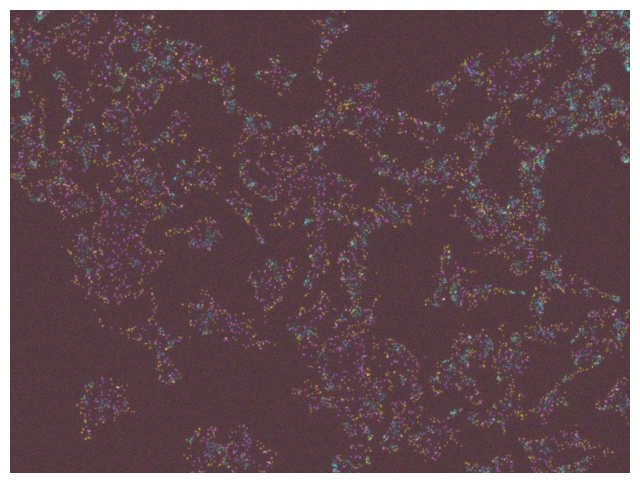

In [ ]:
overlay_labels(image[2:,:,:])

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

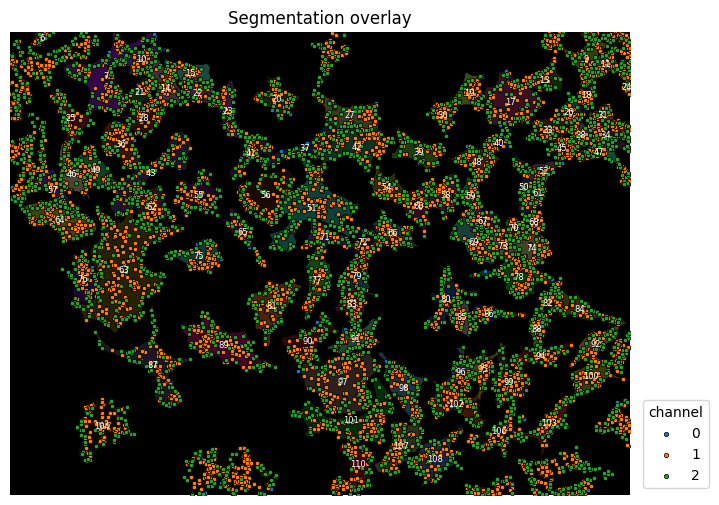

In [ ]:
overlay_labels(label_mask=mask, coordinates=df_spots)

Using the `focus` attribute in `overlay` we can zoom in to view single objects.

(<Figure size 673.684x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

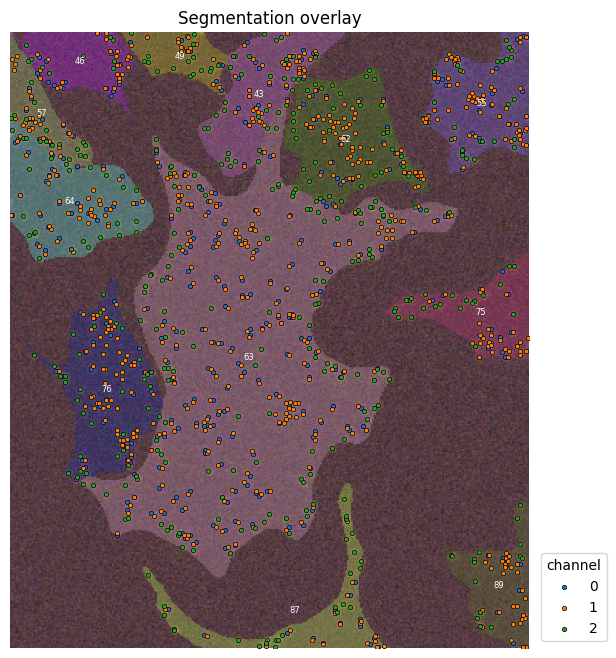

In [ ]:
overlay_labels(image=image[2:,:,:], label_mask=mask, coordinates=df_spots, focus_object=63)

***

## 3. Make An Analysis Plan

### Question
Are the spots clustered?

### Approach 
To answer this question, we need to first define a reference for comparison. A common comparison is **complete spatial randomness (CSR)** (i.e., a fully random distribution of points). We can then define a metric that measures if a collection of points are clustered, and then use this metric to compare our dataset collection of points to a collection of random points. 

### Metric for Clustering
Here, we use the **average distance of each point to its nearest neighbour** as the metric for clustering.

### Workflow

#### 1. Generate a reference for comparison
Randomly distributed set of points inside each cell's cytoplasm. We will call this the **random dataset**, which we will compare to our **protein dataset**.

#### 2. Measure the nearest neighbor distance
For each spot, identify the closest spot within a cell and measure the distance. 

#### 3. Calculate the average nearest neighbour distance
For each dataset, calculate the average nearest neighbor distance for a spot.  

#### 4. Calculate the Clark-Evans Index
The Clark-Evans Index is a ratio between the average nearest neighbour distances for the **protein dataset** and the **random dataset**. This index represents how random or clustered the dot protein distribution is.
    - **Ratio = 1:** The distribution is random 
    - **Ratio > 1:** The distribution is clusered

#### 5. Calculate the p-value of the Clark-Evans Index
Calculate the p-value using a comparison of multiple random patterns.


To start, we focus on **Protein A (Channel 2).**

***

## 4. Assemble the Protein Dataset and the Random Dataset

### Protein Dataset: Map spots to cells and count spots per cell
We need to know how many points are within each cell to place the same number of random points in the next step. If we would generate more or less random points, we would artificially measure clustering or dispersion.

First we generate a dataframe for the cells by using `regionprops_table`.

In [8]:
df_cell = pd.DataFrame(skimage.measure.regionprops_table(
        mask, properties=["area", "label"]
    ))
print(df_cell)

       area  label
0     813.0      6
1   12236.0      7
2    3897.0      9
3    4029.0     10
4    2124.0     11
..      ...    ...
89  10682.0    104
90   6146.0    106
91   6745.0    107
92   7501.0    108
93   4718.0    110

[94 rows x 2 columns]


Then we count the spots per cell (like in Exercise B: Nested Objects).

In [9]:
# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = df_spots.loc[df_spots['channel'] == 0]["label_cell"].value_counts().reset_index()
# add the cell count to the cell dataframe
df_cell = (
    df_cell
    .merge(mapping_spots, left_on="label", right_on="label_cell", how="inner")
    .drop(columns="label_cell")
)
print(df_spots)
print(df_cell)

       channel     y    x  label_cell
87           0    13   69           6
88           0     7   69           6
89           0     7   70           6
90           0    10   66           6
91           0    87  157           7
...        ...   ...  ...         ...
14617        2  1007  800         110
14618        2   978  790         110
14619        2   942  750         110
14620        2  1006  804         110
14621        2   988  809         110

[12488 rows x 4 columns]
       area  label  count
0     813.0      6      4
1   12236.0      7     61
2    3897.0      9     19
3    4029.0     10     20
4    2124.0     11     10
..      ...    ...    ...
89  10682.0    104     53
90   6146.0    106     30
91   6745.0    107     33
92   7501.0    108     37
93   4718.0    110     23

[94 rows x 3 columns]


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

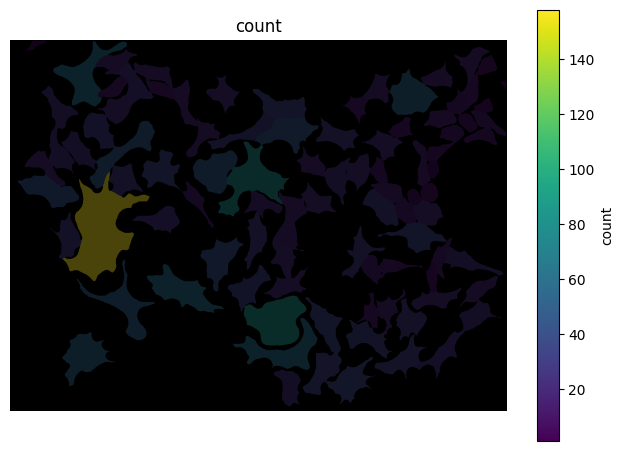

In [ ]:
overlay_labels(label_mask=mask, df=df_cell, id_col='label', measurement_col='count')

### Random Dataset: Generate random points
Let's generate our first set of random points. To make it more transparent, let's focus on a single cell first.

(<Figure size 673.684x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

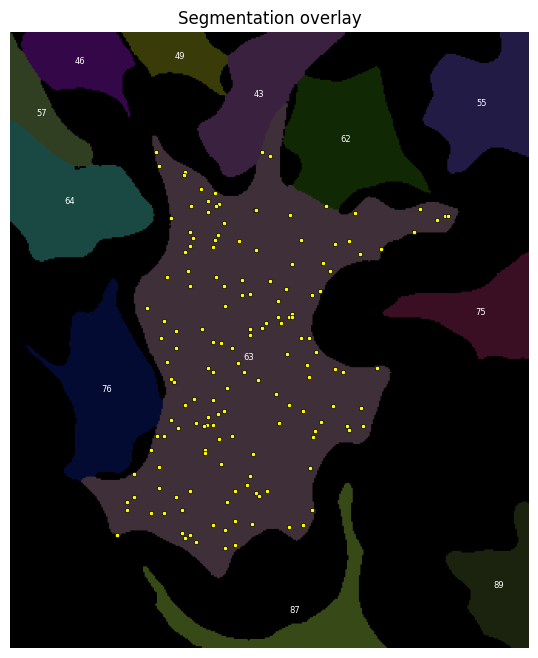

In [ ]:
cell_id = 63
spots = df_spots.loc[(df_spots['channel']==0) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()

overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

We can use a pre-written function to generate the random points. In short, what it does is:
* It calculates the bounding box of the cell (the box that touches the edge of the cell at every side).
* It draws random points inside that box and tests if they fall within the cell.
    * If not, the point is discarded.
    * If it is within the cell it is kept.
This sequence is repeated until the cell contains the specified number of points.

This procedure is necessary since cells have irregular shapes.

In [12]:
def random_points_in_mask(mask, cell_label, n):
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)


Look up how many points are in our cell of interest.

In [13]:
n_points = df_cell.loc[df_cell['label']==cell_id]['count'].values[0]
print(n_points)

158


Create the same number of random points inside that cell.

In [14]:
rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
rnd_points.shape

(158, 2)

(<Figure size 673.684x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

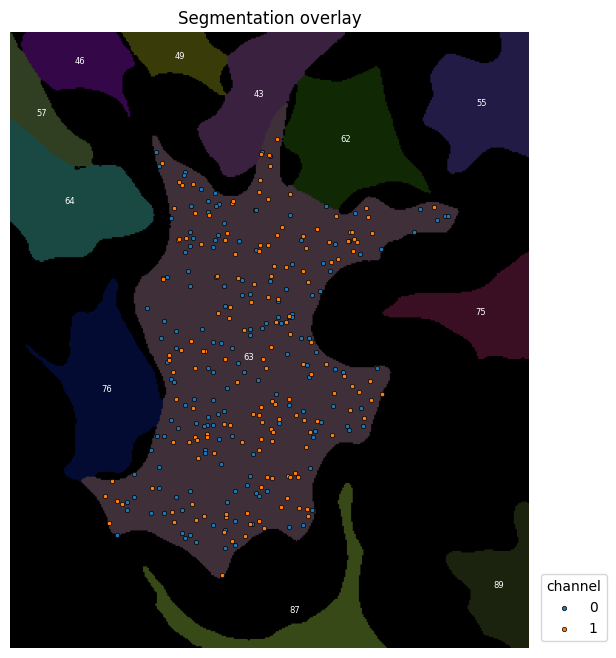

In [ ]:
overlay_labels(label_mask=mask, coordinates=[spots, rnd_points], focus_object=cell_id)

***

## 5. Calculate Nearest Neighbor Distances

### Identifying Neighbors: KD Trees
Now that we have two sets of points, our protein dataset and the random dataset as a control, we can find the nearest neighbour of every point and calculate the distance. To find neighbors, we will use a `KD tree`, a spatial partitioning algorithm that identies neighbours very effectively.

The syntax for the KD tree function is a bit strange at first: 
```python
KDtree(points_A).query(points_B, k=k)
```

- `KDTree(points_A)` builds the KD tree data structure. 
- `.query(points_B, k=k)` computes the distance to the nearest neighbors. It measures the distance from every point in `points_B` to the `k` nearest neighbours in `points_A`. If the two point sets are the same (like in our case), the first distance will be 0, since it is the distance from each point to itself.

In [16]:
dist_spots,_ = KDTree(spots).query(spots, k=2) # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_spots)

[[ 0.         10.        ]
 [ 0.         15.5241747 ]
 [ 0.         12.52996409]
 [ 0.          8.54400375]
 [ 0.          8.48528137]
 [ 0.          9.43398113]
 [ 0.          6.40312424]
 [ 0.         10.        ]
 [ 0.          9.43398113]
 [ 0.          3.60555128]
 [ 0.          4.47213595]
 [ 0.          2.        ]
 [ 0.          2.23606798]
 [ 0.         10.81665383]
 [ 0.          4.12310563]
 [ 0.          8.94427191]
 [ 0.          5.38516481]
 [ 0.         10.63014581]
 [ 0.          8.24621125]
 [ 0.          7.07106781]
 [ 0.          6.40312424]
 [ 0.          3.60555128]
 [ 0.          2.        ]
 [ 0.          5.83095189]
 [ 0.          2.23606798]
 [ 0.          2.82842712]
 [ 0.         19.6468827 ]
 [ 0.          7.61577311]
 [ 0.          8.24621125]
 [ 0.          8.60232527]
 [ 0.          4.        ]
 [ 0.          2.        ]
 [ 0.          5.09901951]
 [ 0.          6.32455532]
 [ 0.         10.29563014]
 [ 0.          8.48528137]
 [ 0.          8.60232527]
 

We do the same for the random spots.

In [17]:
dist_rnd,_ = KDTree(rnd_points).query(rnd_points, k=2) # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_rnd)

[[ 0.          0.86635269]
 [ 0.          3.39558703]
 [ 0.          5.55177675]
 [ 0.         10.76243607]
 [ 0.          5.78676835]
 [ 0.          3.33634541]
 [ 0.          9.62433162]
 [ 0.          0.78454626]
 [ 0.          4.50554266]
 [ 0.          7.07134261]
 [ 0.          4.79044049]
 [ 0.         23.32970445]
 [ 0.         11.01639802]
 [ 0.          5.55177675]
 [ 0.          4.79044049]
 [ 0.          7.0002352 ]
 [ 0.          8.42477962]
 [ 0.          7.76603762]
 [ 0.          0.69197207]
 [ 0.          7.34623999]
 [ 0.          1.00145726]
 [ 0.          6.84835791]
 [ 0.          8.70774231]
 [ 0.         15.04173301]
 [ 0.         11.85770826]
 [ 0.          7.84141139]
 [ 0.          6.81679769]
 [ 0.          8.51186192]
 [ 0.          3.02753953]
 [ 0.          7.8276484 ]
 [ 0.          1.89090447]
 [ 0.          8.12872914]
 [ 0.          7.96971618]
 [ 0.          8.37360062]
 [ 0.          1.51537881]
 [ 0.          1.89090447]
 [ 0.          7.74157281]
 

***

## 6. Calculate the Clark-Evans Index for the protein and random datasets

Now, let's calculate the mean nearest neighbour distances for both spot patterns and compare them using the Clark-Evans Index.

In [18]:
spot_dist_avg = dist_spots[:,1].mean()
rnd_dist_avg = dist_rnd[:,1].mean()
print('Mean NN distance spots:', spot_dist_avg)
print('Mean NN distance random:', rnd_dist_avg)
print('Clark-Evans index (ratio):', spot_dist_avg/rnd_dist_avg)

Mean NN distance spots: 7.789777879704962
Mean NN distance random: 7.2747540876663015
Clark-Evans index (ratio): 1.0707960414650768


***

## 7. Repeat Steps 4-6 with Multiple Random Patterns

### Concept
A single random pattern as a control dataset is not a reliable comparison because a random patten could be clustered by chance. To account for this possibility, we repeat this procedure with additional random patterns.

In [ ]:
n_repeats = 10

list_rnd_dist = [] # this list holds the average NN distances of the random points for each run
list_ce_index = [] # this list holds the Clark-Evans indices for each run


for i in range(n_repeats):
    rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
    dist_rnd,_ = KDTree(rnd_points).query(rnd_points, k=2)
    rnd_dist_avg = dist_rnd[:,1].mean()
    list_rnd_dist.append(rnd_dist_avg)
    list_ce_index.append(spot_dist_avg/rnd_dist_avg)

print('Mean NN distance spots:', spot_dist_avg)
print(f'Mean NN distance spots ({n_repeats} runs):', np.array(list_rnd_dist).mean())
print(f'Mean Clark-Evans index ({n_repeats} runs):', np.array(list_ce_index).mean())



Mean NN distance spots: 7.789777879704962
Mean NN distance spots (10 runs): 7.49079652163105
Mean Clark-Evans index (10 runs): 1.0418780255376885


Can we trust this metric now? A little more, but it would be great to have a p-value. We can calculate the p-value by asking 'In what fraction of the runs was the observed NN distance smaller than random?'.

In [20]:
runs_rnd_smaller =  np.array(list_rnd_dist) <= spot_dist_avg
print(runs_rnd_smaller)

[ True  True  True  True False False False  True  True  True]


The fraction of `True`s in this list is our p-value. 

* Clustered spots → NND_observed is small → most simulations produce a larger NND → few simulations have NND_sim ≤ NND_obs → p close to 0
* Random spots → NND_observed is typical → roughly half the simulations fall below it → p ≈ 0.5

In [21]:
pval = runs_rnd_smaller.mean()
print('p-value for CE index:', pval)

p-value for CE index: 0.7


***

## 8. Repeat Measurements for All Cells

So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

### ✍️ Exercise: Summarise the per-cell clustering analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `NNDist`.
The function should have the following features:

**Parameters:**
* spots : (n, 2) numpy array
    Spot coordinates in (row, col) / (y, x) order.
* mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
* cell_id : int
    ID of the cell in mask that spots belong to.
* n_repeats : int
    Number of CSR simulations to run.

**Returns**
* spot_dist_avg : float
    Mean nearest-neighbor distance of the observed spots.
* rnd_dist_avg : float
    Mean of the per-simulation mean nearest-neighbor distances under CSR.
* clark_evans : float
    Clark-Evans index: spot_dist_avg / rnd_dist_avg.
* p_value : float
    Fraction of CSR simulations with mean NND <= spot_dist_avg.


In [22]:
def NNDist(spots, mask, cell_id, n_repeats):
    """
    Test whether spots in a cell are randomly distributed using nearest-neighbor
    distances and a Monte Carlo simulation of Complete Spatial Randomness (CSR).

    For each simulation run, n_repeats random point patterns are generated inside
    the cell mask and their mean nearest-neighbor distance is computed. The
    Clark-Evans index (observed / random NND) and a Monte Carlo p-value are
    derived from this null distribution.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    spot_dist_avg : float
        Mean nearest-neighbor distance of the observed spots.
    rnd_dist_avg : float
        Mean of the per-simulation mean nearest-neighbor distances under CSR.
    clark_evans : float
        Clark-Evans index: spot_dist_avg / rnd_dist_avg.
        < 1 indicates clustering, > 1 indicates dispersion.
    p_value : float
        Fraction of CSR simulations with mean NND <= spot_dist_avg.
        Small values (< 0.05) indicate significant clustering.
    """
    n_points = spots.shape[0]

    dist_spots, _ = KDTree(spots).query(spots, k=2)
    spot_dist_avg = dist_spots[:, 1].mean()  # k=2: column 0 is self, column 1 is nearest neighbor

    list_rnd_dist = []
    list_ce_index = []
    for i in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
        rnd_dist_avg = dist_rnd[:, 1].mean()
        list_rnd_dist.append(rnd_dist_avg)
        list_ce_index.append(spot_dist_avg / rnd_dist_avg)

    pval = (np.array(list_rnd_dist) <= spot_dist_avg).mean()

    return spot_dist_avg, np.array(list_rnd_dist).mean(), np.array(list_ce_index).mean(), pval


NNDist(spots, mask, cell_id, 100)



(np.float64(7.789777879704962),
 np.float64(7.5170548544982125),
 np.float64(1.038400209265992),
 np.float64(0.78))

In [ ]:
channel = 0
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[(df_spots['label_cell'] == row['label']) &
                             (df_spots['channel']==channel)][['y', 'x']].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row['label'], n_repeats=n_repeats))

df_cell[['nnd_observed', 'nnd_random', 'clark_evans', 'p_value']] = results
df_cell

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/2932270703.py:47: RuntimeWarning: invalid value encountered in scalar divide
  list_ce_index.append(spot_dist_avg / rnd_dist_avg)


,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,813.0,6,4,2.621320,8.723273,0.346478,0.0
1,12236.0,7,61,6.224340,7.966764,0.783937,0.0
2,3897.0,9,19,6.423956,8.264161,0.786613,0.0
3,4029.0,10,20,8.929209,7.916795,1.135395,1.0
4,2124.0,11,10,9.007935,8.183254,1.140789,0.6
...,...,...,...,...,...,...,...
89,10682.0,104,53,7.853425,7.830480,1.011293,0.7
90,6146.0,106,30,8.736020,8.472386,1.043741,0.6
91,6745.0,107,33,7.394869,8.472442,0.876339,0.0
92,7501.0,108,37,8.195712,8.541080,0.970702,0.3


In [24]:
df_cell.loc[df_cell['label']==cell_id]

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
49,31664.0,63,158,7.789778,7.332887,1.064259,0.9


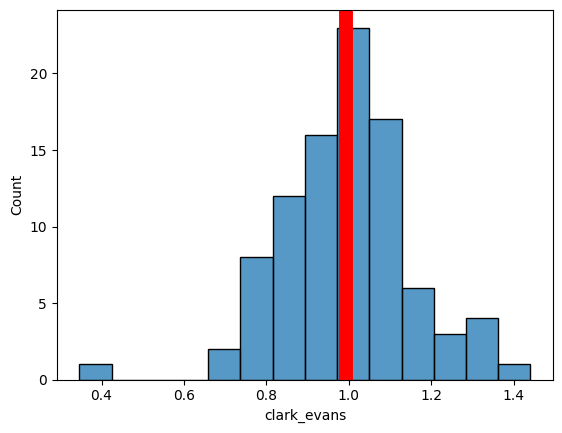

In [25]:
sns.histplot(
    df_cell,
    x='clark_evans',
)
plt.axvline(df_cell['clark_evans'].mean(), c='red', lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

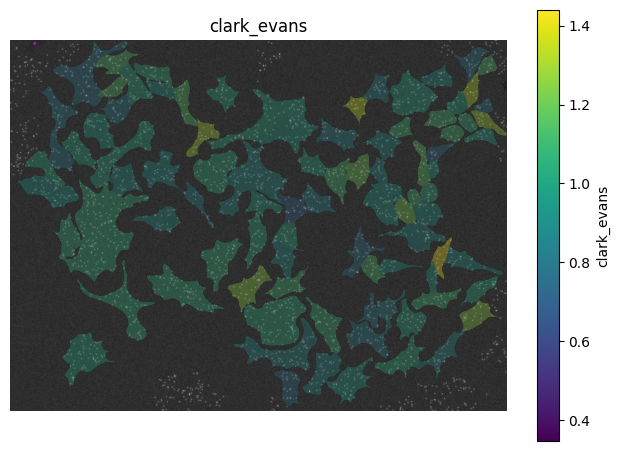

In [ ]:
overlay_labels(image=image[2,:,:], label_mask=mask, df=df_cell, id_col='label', measurement_col='clark_evans')

***

## 9. Perform the Same Calculation on the Other Channels
Let's use the tools we developed above to see if the spots in the other channels.

**Channel 1**

In [ ]:
channel = 1
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[(df_spots['label_cell'] == row['label']) &
                             (df_spots['channel']==channel)][['y', 'x']].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row['label'], n_repeats=n_repeats))

df_cell[['nnd_observed', 'nnd_random', 'clark_evans', 'p_value']] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,813.0,6,4,1.624836,2.092581,0.783669,0.1
1,12236.0,7,61,4.407303,5.734767,0.769693,0.0
2,3897.0,9,19,3.524946,4.220414,0.836395,0.0
3,4029.0,10,20,2.900196,4.151315,0.700929,0.0
4,2124.0,11,10,2.903812,3.221471,0.903688,0.0
...,...,...,...,...,...,...,...
89,10682.0,104,53,4.567848,5.386075,0.848731,0.0
90,6146.0,106,30,4.395955,4.729827,0.938710,0.3
91,6745.0,107,33,4.144519,4.873712,0.851252,0.0
92,7501.0,108,37,4.073854,5.119748,0.800176,0.0


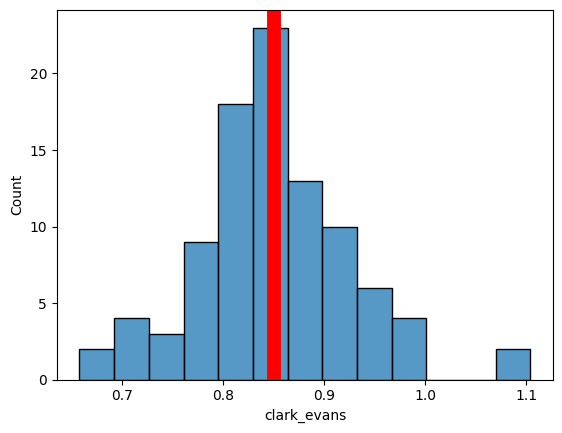

In [28]:
sns.histplot(
    df_cell,
    x='clark_evans',
)
plt.axvline(df_cell['clark_evans'].mean(), c='red', lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

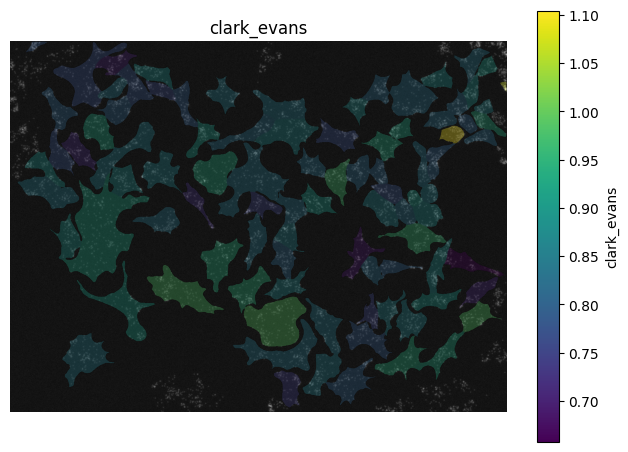

In [ ]:
overlay_labels(image=image[3,:,:], label_mask=mask, df=df_cell, id_col='label', measurement_col='clark_evans')

**Channel 2**

In [ ]:
channel = 2
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[(df_spots['label_cell'] == row['label']) &
                             (df_spots['channel']==channel)][['y', 'x']].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row['label'], n_repeats=n_repeats))

df_cell[['nnd_observed', 'nnd_random', 'clark_evans', 'p_value']] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,813.0,6,4,6.386375,5.841208,1.183311,0.5
1,12236.0,7,61,6.311969,6.802401,0.931204,0.0
2,3897.0,9,19,6.835503,6.882408,1.000944,0.3
3,4029.0,10,20,6.454970,6.530639,1.002395,0.4
4,2124.0,11,10,6.214888,6.674236,0.941602,0.2
...,...,...,...,...,...,...,...
89,10682.0,104,53,5.318296,7.620668,0.699892,0.0
90,6146.0,106,30,5.234533,6.652371,0.792979,0.0
91,6745.0,107,33,6.339555,6.902593,0.925239,0.2
92,7501.0,108,37,7.490188,7.352563,1.020644,0.7


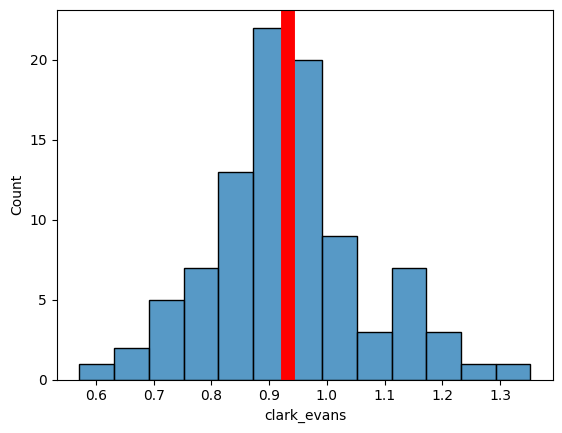

In [31]:
sns.histplot(
    df_cell,
    x='clark_evans',
)
plt.axvline(df_cell['clark_evans'].mean(), c='red', lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_70628/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

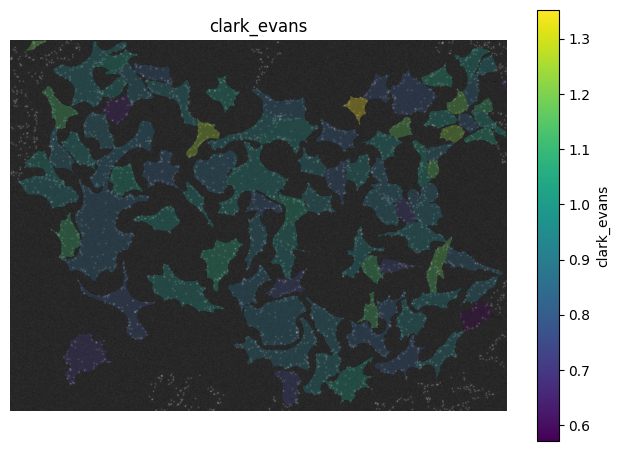

In [ ]:
overlay_labels(image=image[4,:,:], label_mask=mask, df=df_cell, id_col='label', measurement_col='clark_evans')

It seems like **protein A is not clustered**, **protein B is clustering** and protein C is a little ambigous. 

***

## 10. Measure the Length Scale of Clustering: Ripleys L Function
We know that Protein B is clustered compared to random. However, we don't know what scale the clustering is occurring on. 

A common method to investigate the length scales of spatial patterns is **Ripley's L function**. The idea is to calculate the density of spots around each spot for different radii and compare that to a random point pattern. The density of a random pattern is independent of the radius, while clustered points will exhibit higher density at shorter radii than longer ones. This way we can infer the average cluster size and distance between clusters.

Here, we only demonstrate the concept on the spot pattern of protein B in one cell. 

In [ ]:
from scipy.ndimage import binary_erosion


def RipleysL(spots, mask, cell_id, n_repeats, r_values=None):
    """
    Compute Ripley's L function for spots in a cell against a CSR null model,
    using a Monte Carlo envelope from simulated random point patterns.

    Returns the centered L function L(r) - r, which is 0 under CSR.
    Positive values indicate clustering at scale r, negative values indicate
    dispersion. Border correction is applied via mask erosion: only points at
    least r pixels from the cell boundary are used as source points.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.
    r_values : 1D array or None
        Radii at which to evaluate L(r) - r. Defaults to 30 values from 0
        to half the cell's effective radius.

    Returns
    -------
    r_values : 1D array
        Radii at which L(r) - r was evaluated.
    L_observed : 1D array
        L(r) - r for the observed spots.
    L_sims : (n_repeats, len(r_values)) array
        L(r) - r for each CSR simulation. Use .min(axis=0) / .max(axis=0)
        for the envelope, .mean(axis=0) for the expected value under CSR.
    """
    cell_mask = mask == cell_id
    area = cell_mask.sum()
    n_points = spots.shape[0]

    if r_values is None:
        r_max = np.sqrt(area / np.pi) * 0.5
        r_values = np.linspace(0, r_max, 30)

    # precompute eroded masks for each r — done once, not per simulation
    eroded_masks = []
    for r in r_values:
        r_int = int(np.ceil(r))
        size = 2 * r_int + 1
        cy, cx = np.ogrid[-r_int:size - r_int, -r_int:size - r_int]
        struct = cy**2 + cx**2 <= r**2
        eroded_masks.append(binary_erosion(cell_mask, structure=struct))

    def compute_L(coords):
        tree = KDTree(coords)
        K = []
        for r, eroded in zip(r_values, eroded_masks):
            valid = eroded[coords[:, 0].astype(int), coords[:, 1].astype(int)]
            n_valid = valid.sum()
            if n_valid == 0:
                K.append(np.nan)
                continue
            count = sum(len(tree.query_ball_point(p, r)) - 1 for p in coords[valid])
            K.append((area / (n_valid * n_points)) * count)
        return np.sqrt(np.array(K) / np.pi) - r_values

    L_observed = compute_L(spots)

    L_sims = []
    for _ in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        L_sims.append(compute_L(rnd_points))

    return r_values, L_observed, np.array(L_sims)


(<Figure size 673.684x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

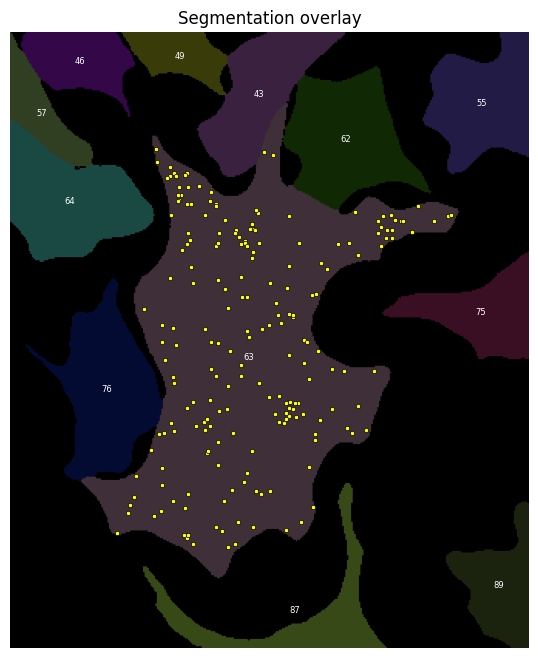

In [ ]:
cell_id = 63
spots = df_spots.loc[(df_spots['channel']==1) & (df_spots['label_cell']==cell_id)][['y', 'x']].to_numpy()
overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

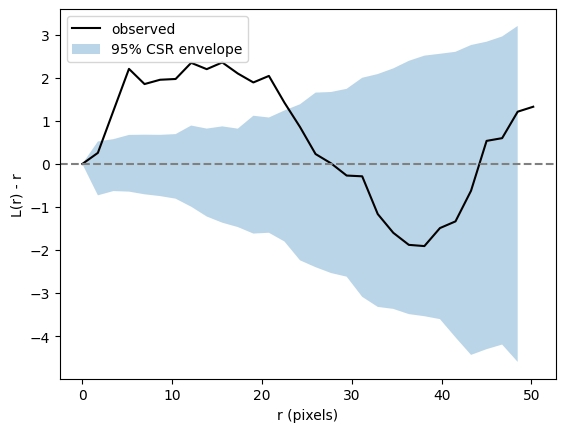

In [35]:
r_values, L_obs, L_sims = RipleysL(spots, mask, cell_id=63, n_repeats=200)

plt.plot(r_values, L_obs, color='black', label='observed')
plt.fill_between(r_values,
                 np.percentile(L_sims, 2.5, axis=0),
                 np.percentile(L_sims, 97.5, axis=0),
                 alpha=0.3, label='95% CSR envelope')

plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('r (pixels)')
plt.ylabel('L(r) - r')
plt.legend()


We observe clustering with scale 2-20 pixels, where the observed curve is above the 95% CSR envelope.